# Adım Adım Veri Analizi
Bu not defteri, yüklenen Malatya su, yağış, iklim ve sosyoekonomik veri setleri için adım adım veri analizi işlemlerini açık ve karışıklığa yer vermeden gösterir.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO

sns.set(style='whitegrid', palette='muted', font_scale=1.05)

csv_files = sorted(Path('.').glob('*.csv'))
print('CSV dosyaları:')
for f in csv_files:
    print('-', f.name)


CSV dosyaları:
- malatya_gunluk_su_tuketimi_20yil.csv
- malatya_gunluk_yagis_20yil.csv
- malatya_iklim_senaryosu_2024_2053.csv
- malatya_kayip_kacak_20yil.csv
- malatya_nufus_projeksiyonu_2024_2053.csv
- malatya_sektorel_tuketim_tarimli_20yil.csv
- malatya_sosyoekonomik_20yil.csv
- veri_seti.csv


## 1. Veri Yükleme
Her bir CSV dosyasını pandas ile okuyacağız. Bazı dosyalarda tüm satırları tırnak içinde gösteren format var; bu yüzden bu tür durumlar için özel bir yükleme fonksiyonu kullanıyoruz.

In [2]:
def read_csv_robust(path):
    text = Path(path).read_text(encoding='utf-8').strip()
    if text.startswith('"') and '\n"' in text:
        text = '\n'.join(line.strip('"') for line in text.splitlines())
    return pd.read_csv(StringIO(text), sep=',', decimal='.', encoding='utf-8')

raw_data = {}
for csv_path in csv_files:
    df = read_csv_robust(csv_path)
    raw_data[csv_path.name] = df

raw_data.keys()


dict_keys(['malatya_gunluk_su_tuketimi_20yil.csv', 'malatya_gunluk_yagis_20yil.csv', 'malatya_iklim_senaryosu_2024_2053.csv', 'malatya_kayip_kacak_20yil.csv', 'malatya_nufus_projeksiyonu_2024_2053.csv', 'malatya_sektorel_tuketim_tarimli_20yil.csv', 'malatya_sosyoekonomik_20yil.csv', 'veri_seti.csv'])

## 2. Veri Keşfi
Her bir veri setinin boyutunu, sütunlarını, veri tiplerini ve ilk satırlarını inceleyeceğiz.

In [3]:
for name, df in raw_data.items():
    print('\n---', name, '---')
    print('Boyut:', df.shape)
    print('\nSütunlar:')
    print(df.columns.tolist())
    print('\nİlk 3 satır:')
    display(df.head(3))



--- malatya_gunluk_su_tuketimi_20yil.csv ---
Boyut: (7305, 4)

Sütunlar:
['Tarih', 'Ort_Sicaklik', 'Hafta_Sonu', 'Su_Tuketimi_m3']

İlk 3 satır:


,Tarih,Ort_Sicaklik,Hafta_Sonu,Su_Tuketimi_m3
0,2004-01-01,-1.7,0,93910
1,2004-01-02,-1.2,0,96421
2,2004-01-03,-5.7,1,102581



--- malatya_gunluk_yagis_20yil.csv ---
Boyut: (7305, 5)

Sütunlar:
['Tarih', 'Karakaya_Yagis_mm', 'Surgu_Yagis_mm', 'Sultansuyu_Yagis_mm', 'Genel_Ortalama_mm']

İlk 3 satır:


,Tarih,Karakaya_Yagis_mm,Surgu_Yagis_mm,Sultansuyu_Yagis_mm,Genel_Ortalama_mm
0,2004-01-01,0.0,0.0,0.0,0.0
1,2004-01-02,0.0,0.0,0.0,0.0
2,2004-01-03,0.0,0.0,0.0,0.0



--- malatya_iklim_senaryosu_2024_2053.csv ---
Boyut: (360, 9)

Sütunlar:
['Tarih', 'Yil', 'Ay', 'Ort_Sicaklik', 'Toplam_Yagis', 'Karakaya_Doluluk', 'Surgu_Doluluk', 'Sultansuyu_Doluluk', 'Genel_Ortalama']

İlk 3 satır:


...

,Tarih,Toplam_Tuketim_m3,Hane_m3,Sanayi_m3,Tarim_m3,Diger_m3
0,2004-01-01,3552154,2483069,643528,73207,352350
1,2004-02-01,3475413,2427093,635453,70575,342292
2,2004-03-01,3450705,2428599,618248,68371,335487



--- malatya_sosyoekonomik_20yil.csv ---
Boyut: (20, 4)

Sütunlar:
['Yil', 'Su_Tarifesi_TL_m3', 'Kisi_Basi_Gelir_USD', 'Ziyaretci_Sayisi_Aylik_Ort']

İlk 3 satır:


,Yil,Su_Tarifesi_TL_m3,Kisi_Basi_Gelir_USD,Ziyaretci_Sayisi_Aylik_Ort
0,2004,0.65,4200,18500
1,2005,0.72,5000,19200
2,2006,0.85,5500,20500



--- veri_seti.csv ---
Boyut: (240, 8)

Sütunlar:
['Yil', 'Ay', 'Karakaya_Doluluk', 'Surgu_Doluluk', 'Sultansuyu_Doluluk', 'Genel_Ortalama', 'Ort_Sicaklik', 'Toplam_Yagis']

İlk 3 satır:


,Yil,Ay,Karakaya_Doluluk,Surgu_Doluluk,Sultansuyu_Doluluk,Genel_Ortalama,Ort_Sicaklik,Toplam_Yagis
0,2004,1,58.0,60.0,62.0,60.0,2.1,45.0
1,2004,2,60.0,63.0,64.0,62.3,3.5,40.0
2,2004,3,65.0,70.0,68.0,67.6,8.5,55.0


In [4]:
for name, df in raw_data.items():
    print('\n---', name, '---')
    print(df.dtypes)
    print('Eksik değer sayısı:')
    print(df.isnull().sum())



--- malatya_gunluk_su_tuketimi_20yil.csv ---
Tarih              object
Ort_Sicaklik      float64
Hafta_Sonu          int64
Su_Tuketimi_m3      int64
dtype: object
Eksik değer sayısı:
Tarih             0
Ort_Sicaklik      0
Hafta_Sonu        0
Su_Tuketimi_m3    0
dtype: int64

--- malatya_gunluk_yagis_20yil.csv ---
Tarih                   object
Karakaya_Yagis_mm      float64
Surgu_Yagis_mm         float64
Sultansuyu_Yagis_mm    float64
Genel_Ortalama_mm      float64
dtype: object
Eksik değer sayısı:
Tarih                  0
Karakaya_Yagis_mm      0
Surgu_Yagis_mm         0
Sultansuyu_Yagis_mm    0
Genel_Ortalama_mm      0
dtype: int64

--- malatya_iklim_senaryosu_2024_2053.csv ---
Tarih                  object
Yil                     int64
Ay                      int64
Ort_Sicaklik          float64
Toplam_Yagis          float64
Karakaya_Doluluk      float64
Surgu_Doluluk         float64
Sultansuyu_Doluluk    float64
Genel_Ortalama        float64
dtype: object
Eksik değer sayısı:
Tarih

## 3. Eksik Değerlerin Yönetimi
Eksik değer varsa belirleyeceğiz ve eğer makul ise nasıl doldurulabileceğini göstereceğiz.

In [5]:
missing_summary = pd.DataFrame(
    [(name, df.isnull().sum().sum(), df.isnull().sum().to_dict()) for name, df in raw_data.items()],
    columns=['Veri Seti', 'Toplam Eksik', 'Sütun Bazlı Eksik']
)
missing_summary


,Veri Seti,Toplam Eksik,Sütun Bazlı Eksik
0,malatya_gunluk_su_tuketimi_20yil.csv,0,"{'Tarih': 0, 'Ort_Sicaklik': 0, 'Hafta_Sonu': ..."
1,malatya_gunluk_yagis_20yil.csv,0,"{'Tarih': 0, 'Karakaya_Yagis_mm': 0, 'Surgu_Ya..."
2,malatya_iklim_senaryosu_2024_2053.csv,0,"{'Tarih': 0, 'Yil': 0, 'Ay': 0, 'Ort_Sicaklik'..."
3,malatya_kayip_kacak_20yil.csv,0,"{'Tarih': 0, 'Bolge_Tipi': 0, 'Nufus': 0, 'Alt..."
4,malatya_nufus_projeksiyonu_2024_2053.csv,0,"{'Yil': 0, 'Toplam_Nufus': 0, 'Kentsel_Nufus':..."
5,malatya_sektorel_tuketim_tarimli_20yil.csv,0,"{'Tarih': 0, 'Toplam_Tuketim_m3': 0, 'Hane_m3'..."
6,malatya_sosyoekonomik_20yil.csv,0,"{'Yil': 0, 'Su_Tarifesi_TL_m3': 0, 'Kisi_Basi_..."
7,veri_seti.csv,0,"{'Yil': 0, 'Ay': 0, 'Karakaya_Doluluk': 0, 'Su..."


Veri setlerinizde şu anda ekran çıktısına göre doğrudan eksik kayıt görünmüyor. Eğer varsa, aşağıdaki yöntemlerle işleyebiliriz.

In [6]:
cleaned_data = {}
for name, df in raw_data.items():
    df_clean = df.copy()
    df_clean = df_clean.dropna()  # eksik satırları atar
    cleaned_data[name] = df_clean
    print(name, '->', df.shape, 'boyutundan', df_clean.shape, 'boyuta düştü')


malatya_gunluk_su_tuketimi_20yil.csv -> (7305, 4) boyutundan (7305, 4) boyuta düştü
malatya_gunluk_yagis_20yil.csv -> (7305, 5) boyutundan (7305, 5) boyuta düştü
malatya_iklim_senaryosu_2024_2053.csv -> (360, 9) boyutundan (360, 9) boyuta düştü
malatya_kayip_kacak_20yil.csv -> (720, 10) boyutundan (720, 10) boyuta düştü
malatya_nufus_projeksiyonu_2024_2053.csv -> (30, 6) boyutundan (30, 6) boyuta düştü
malatya_sektorel_tuketim_tarimli_20yil.csv -> (240, 6) boyutundan (240, 6) boyuta düştü
malatya_sosyoekonomik_20yil.csv -> (20, 4) boyutundan (20, 4) boyuta düştü
veri_seti.csv -> (240, 8) boyutundan (240, 8) boyuta düştü


## 4. Yinelenen Kayıtların Kontrolü ve Temizlenmesi
Tekrarlanan satır varsa bunları sileriz.

In [7]:
for name, df in cleaned_data.items():
    duplicate_count = df.duplicated().sum()
    print(name, 'tekrarlanan satır sayısı:', duplicate_count)
    if duplicate_count > 0:
        cleaned_data[name] = df.drop_duplicates()
        print('  Düzeltilmiş boyut:', cleaned_data[name].shape)


malatya_gunluk_su_tuketimi_20yil.csv tekrarlanan satır sayısı: 0
malatya_gunluk_yagis_20yil.csv tekrarlanan satır sayısı: 0
malatya_iklim_senaryosu_2024_2053.csv tekrarlanan satır sayısı: 0
malatya_kayip_kacak_20yil.csv tekrarlanan satır sayısı: 0
malatya_nufus_projeksiyonu_2024_2053.csv tekrarlanan satır sayısı: 0
malatya_sektorel_tuketim_tarimli_20yil.csv tekrarlanan satır sayısı: 0
malatya_sosyoekonomik_20yil.csv tekrarlanan satır sayısı: 0
veri_seti.csv tekrarlanan satır sayısı: 0


## 5. Veri Tipi Dönüşümü
Tarih sütunlarını gerçek `datetime` tipine çeviriyoruz ve sayısal olmayan sütunları sayısal tipe dönüştürüyoruz.

In [8]:
def convert_types(df):
    out = df.copy()
    if 'Tarih' in out.columns:
        out['Tarih'] = pd.to_datetime(out['Tarih'], errors='coerce')
    if 'Yil' in out.columns and out['Yil'].dtype == object:
        out['Yil'] = pd.to_numeric(out['Yil'], errors='coerce').astype('Int64')
    for col in out.columns:
        if out[col].dtype == object and col not in ['Tarih', 'Bolge_Tipi']:
            out[col] = pd.to_numeric(out[col].str.replace(',', '.'), errors='ignore')
    return out

typed_data = {name: convert_types(df) for name, df in cleaned_data.items()}
for name, df in typed_data.items():
    print('\n---', name, '---')
    print(df.dtypes)



--- malatya_gunluk_su_tuketimi_20yil.csv ---
Tarih             datetime64[ns]
Ort_Sicaklik             float64
Hafta_Sonu                 int64
Su_Tuketimi_m3             int64
dtype: object

--- malatya_gunluk_yagis_20yil.csv ---
Tarih                  datetime64[ns]
Karakaya_Yagis_mm             float64
Surgu_Yagis_mm                float64
Sultansuyu_Yagis_mm           float64
Genel_Ortalama_mm             float64
dtype: object

--- malatya_iklim_senaryosu_2024_2053.csv ---
Tarih                 datetime64[ns]
Yil                            int64
Ay                             int64
Ort_Sicaklik                 float64
Toplam_Yagis                 float64
Karakaya_Doluluk             float64
Surgu_Doluluk                float64
Sultansuyu_Doluluk           float64
Genel_Ortalama               float64
dtype: object

--- malatya_kayip_kacak_20yil.csv ---
Tarih                     datetime64[ns]
Bolge_Tipi                        object
Nufus                              int64
Altyapi_

## 6. Tanımlayıcı İstatistikler
Sayısal sütunlar için özet istatistikleri hesaplayarak verinin dağılımını ve merkezi eğilim değerlerini görürüz.

In [9]:
for name, df in typed_data.items():
    print('\n===', name, '===')
    display(df.describe(include='all'))



=== malatya_gunluk_su_tuketimi_20yil.csv ===


,Tarih,Ort_Sicaklik,Hafta_Sonu,Su_Tuketimi_m3
count,7305,7305.000000,7305.000000,7305.000000
mean,2013-12-31 00:00:00,15.011253,0.285832,151709.847228
min,2004-01-01 00:00:00,-10.100000,0.000000,89671.000000
25%,2008-12-31 00:00:00,4.400000,0.000000,133304.000000
50%,2013-12-31 00:00:00,15.100000,0.000000,151396.000000
75%,2018-12-31 00:00:00,25.900000,1.000000,170389.000000
max,2023-12-31 00:00:00,39.500000,1.000000,217373.000000
std,NaN,11.687267,0.451841,25666.587529



=== malatya_gunluk_yagis_20yil.csv ===


,Tarih,Karakaya_Yagis_mm,Surgu_Yagis_mm,Sultansuyu_Yagis_mm,Genel_Ortalama_mm
count,7305,7305.000000,7305.000000,7305.000000,7305.000000
mean,2013-12-31 00:00:00,1.076181,1.318823,1.250801,1.215332
min,2004-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000
25%,2008-12-31 00:00:00,0.000000,0.000000,0.000000,0.000000
50%,2013-12-31 00:00:00,0.000000,0.000000,0.000000,0.000000
75%,2018-12-31 00:00:00,0.200000,0.300000,0.300000,0.300000
max,2023-12-31 00:00:00,31.800000,52.300000,38.600000,40.800000
std,NaN,2.801987,3.474940,3.253206,3.160061



=== malatya_iklim_senaryosu_2024_2053.csv ===


...

,Tarih,Toplam_Tuketim_m3,Hane_m3,Sanayi_m3,Tarim_m3,Diger_m3
count,240,2.400000e+02,2.400000e+02,2.400000e+02,2.400000e+02,2.400000e+02
mean,2013-12-15 23:00:00,7.157016e+06,3.013509e+06,8.376695e+05,2.682861e+06,6.229770e+05
min,2004-01-01 00:00:00,3.344755e+06,1.757386e+06,1.806480e+05,6.830900e+04,3.276100e+05
25%,2008-12-24 06:00:00,4.636955e+06,2.643092e+06,7.437985e+05,9.711450e+04,4.650168e+05
50%,2013-12-16 12:00:00,5.604284e+06,3.027930e+06,8.565500e+05,1.352442e+06,5.642065e+05
75%,2018-12-08 18:00:00,9.835055e+06,3.371795e+06,9.716012e+05,5.877763e+06,7.701060e+05
max,2023-12-01 00:00:00,1.460280e+07,4.345055e+06,1.184370e+06,8.875357e+06,1.314397e+06
std,NaN,3.241697e+06,5.033471e+05,1.879397e+05,3.055549e+06,2.117480e+05



=== malatya_sosyoekonomik_20yil.csv ===


,Yil,Su_Tarifesi_TL_m3,Kisi_Basi_Gelir_USD,Ziyaretci_Sayisi_Aylik_Ort
count,20.00000,20.000000,20.000000,20.000000
mean,2013.50000,3.080000,7235.000000,25400.000000
std,5.91608,3.338419,1378.509874,5528.300396
min,2004.00000,0.650000,4200.000000,15000.000000
25%,2008.75000,1.137500,6425.000000,21600.000000
50%,2013.50000,1.800000,7350.000000,24750.000000
75%,2018.25000,3.675000,8500.000000,29625.000000
max,2023.00000,14.500000,9500.000000,35000.000000



=== veri_seti.csv ===


,Yil,Ay,Karakaya_Doluluk,Surgu_Doluluk,Sultansuyu_Doluluk,Genel_Ortalama,Ort_Sicaklik,Toplam_Yagis
count,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,2013.500000,6.500000,64.056250,63.470833,61.929167,63.120000,15.652083,34.091667
std,5.778332,3.459267,13.321576,17.072059,15.926846,15.352615,9.183143,19.095442
min,2004.000000,1.000000,28.000000,18.000000,20.000000,22.000000,1.800000,0.000000
25%,2008.750000,3.750000,56.000000,52.000000,52.000000,54.000000,7.625000,18.000000
50%,2013.500000,6.500000,65.000000,64.000000,62.000000,63.600000,16.000000,35.000000
75%,2018.250000,9.250000,74.000000,75.000000,74.000000,73.600000,24.000000,48.000000
max,2023.000000,12.000000,95.000000,100.000000,95.000000,96.600000,31.500000,80.000000


## 7. Veri Görselleştirme
Her veri seti için önemli değişkenleri ve zaman serilerini göstererek ilişkileri görselleştireceğiz.


--- malatya_gunluk_su_tuketimi_20yil.csv ---


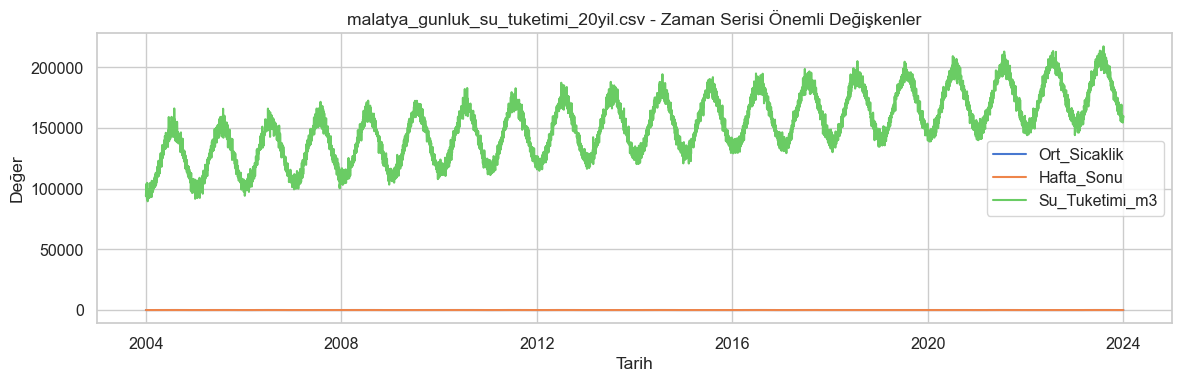


--- malatya_gunluk_yagis_20yil.csv ---


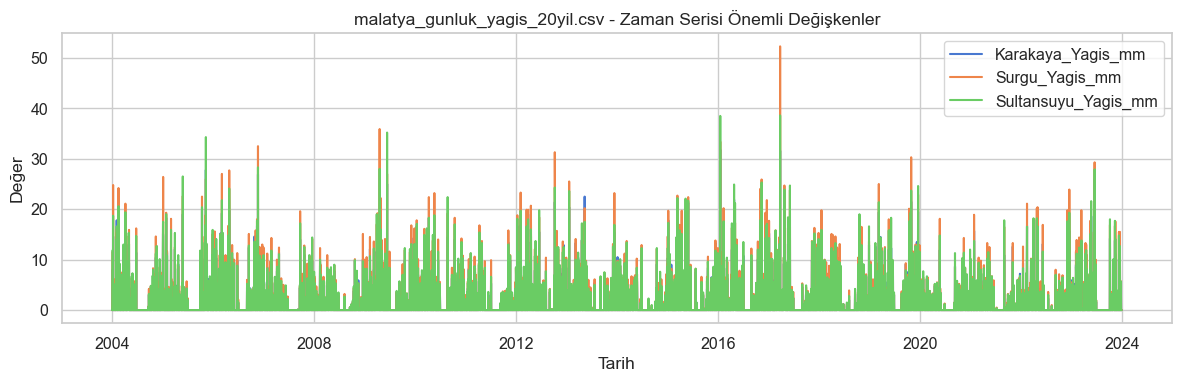


--- malatya_iklim_senaryosu_2024_2053.csv ---


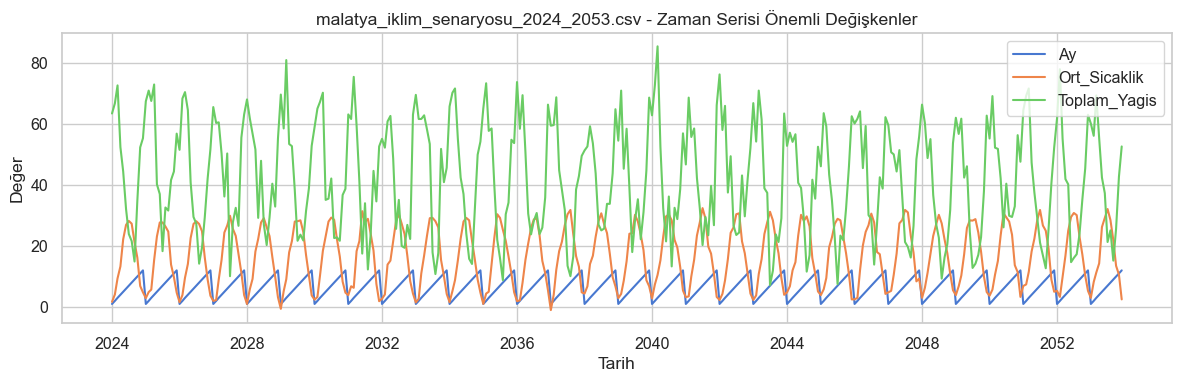


--- malatya_kayip_kacak_20yil.csv ---


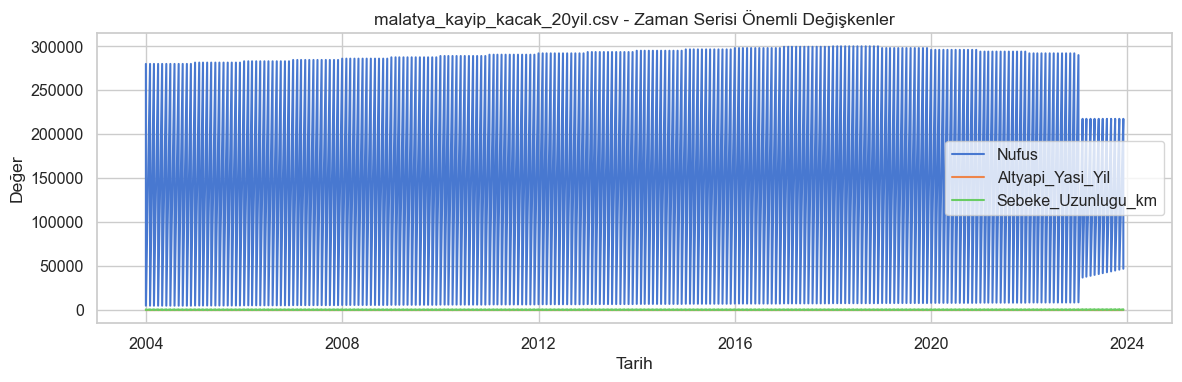


--- malatya_nufus_projeksiyonu_2024_2053.csv ---


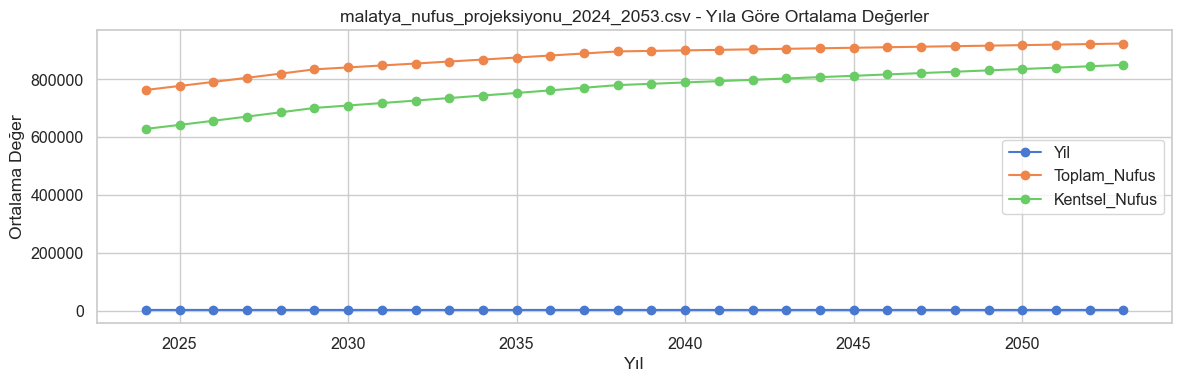


--- malatya_sektorel_tuketim_tarimli_20yil.csv ---


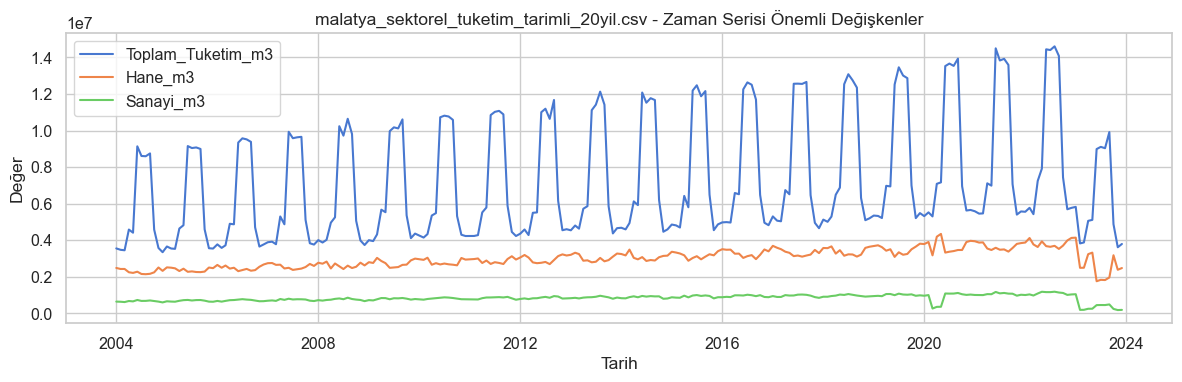


--- malatya_sosyoekonomik_20yil.csv ---


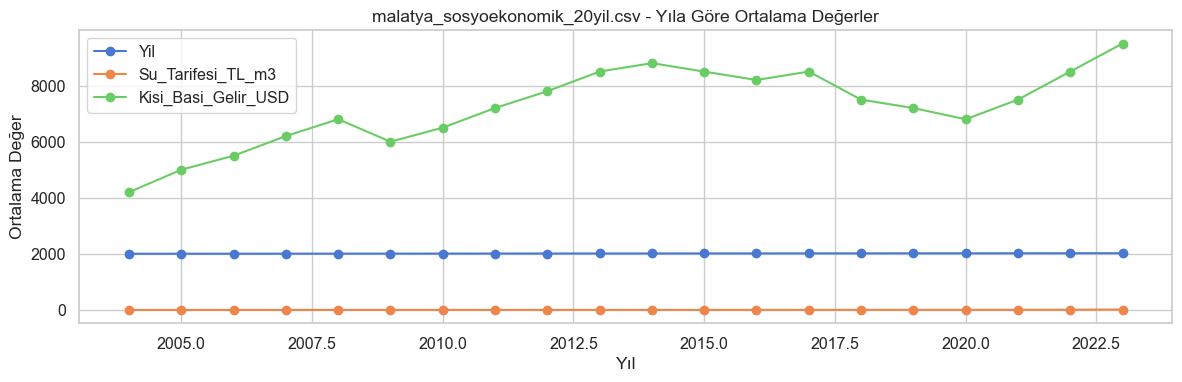


--- veri_seti.csv ---


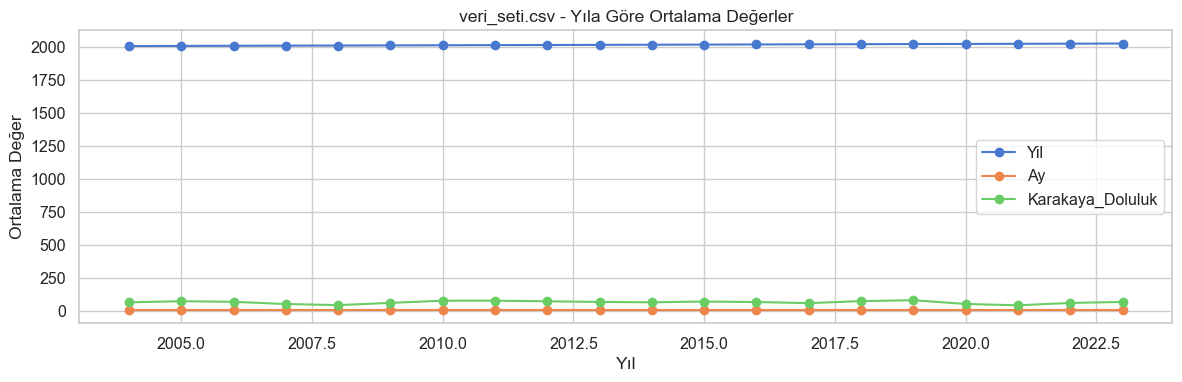

In [12]:
for name, df in typed_data.items():
    print(f"\n--- {name} ---")
    numeric = df.select_dtypes(include=['number'])
    if numeric.empty:
        print('  Sayısal sütun yok, görselleştirme atlandı.')
        continue

    if 'Tarih' in df.columns:
        time_df = df.dropna(subset=['Tarih'])
        if not time_df.empty:
            cols = [c for c in numeric.columns if c != 'Yil'][:3]
            if cols:
                plt.figure(figsize=(12, 4))
                for col in cols:
                    plt.plot(time_df['Tarih'], time_df[col], label=col)
                plt.title(name + ' - Zaman Serisi Önemli Değişkenler')
                plt.xlabel('Tarih')
                plt.ylabel('Değer')
                plt.legend()
                plt.tight_layout()
                plt.show()
            else:
                print('  Grafik için yeterli sayısal sütun yok.')
        else:
            print('  Tarih bilgisi olan veri setinde eksik tarih var.')
    elif 'Yil' in df.columns:
        trend = df.groupby('Yil')[numeric.columns].mean()
        cols = trend.columns[:3]
        plt.figure(figsize=(12, 4))
        for col in cols:
            plt.plot(trend.index, trend[col], marker='o', label=col)
        plt.title(name + ' - Yıla Göre Ortalama Değerler')
        plt.xlabel('Yıl')
        plt.ylabel('Ortalama Değer')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        cols = numeric.columns[:3]
        if len(cols) > 1:
            sns.pairplot(df[cols].dropna())
            plt.suptitle(name + ' - Önemli Sayısal Değişkenler Arasındaki İlişkiler', y=1.02)
            plt.show()
        else:
            print('  Yıla veya tarihe dayalı görselleştirme yapılamadı.')

## 8. Korelasyon Analizi
Her veri seti için sayısal değişkenler arasında korelasyon matrisini hesaplayıp görselleştireceğiz.

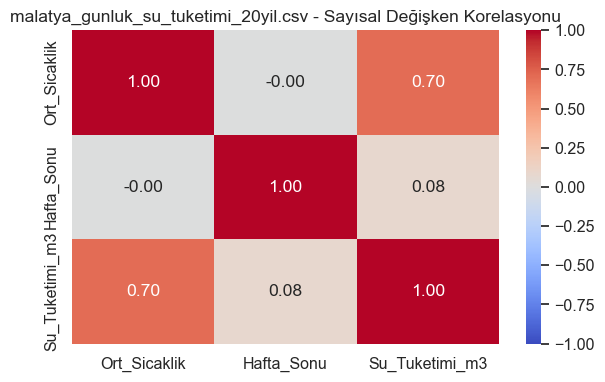

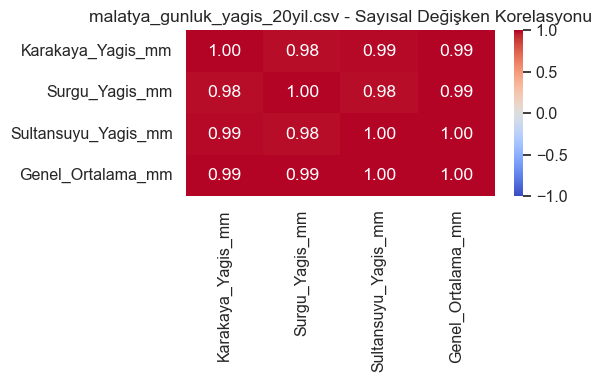

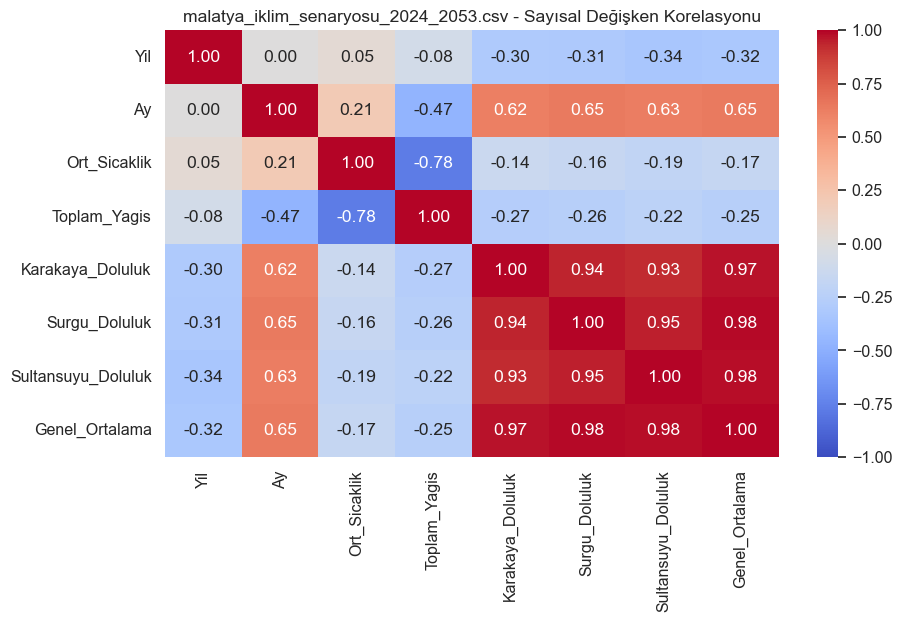

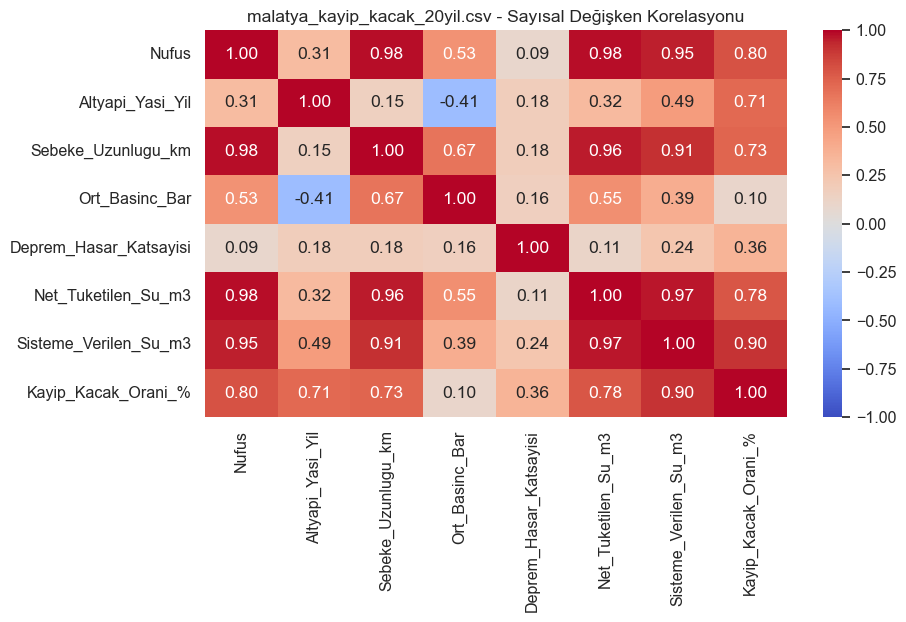

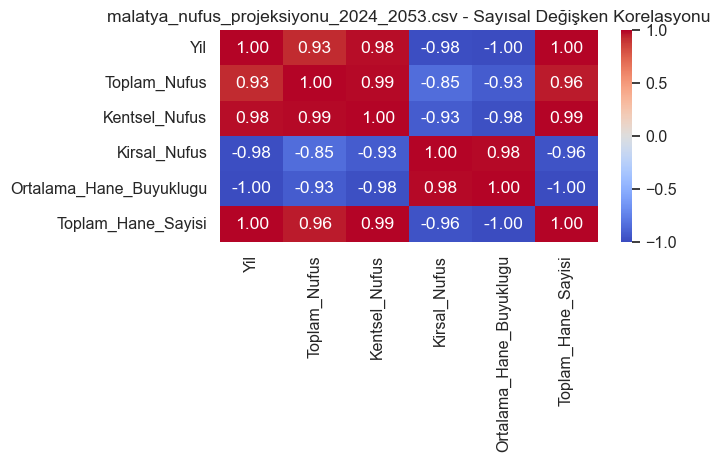

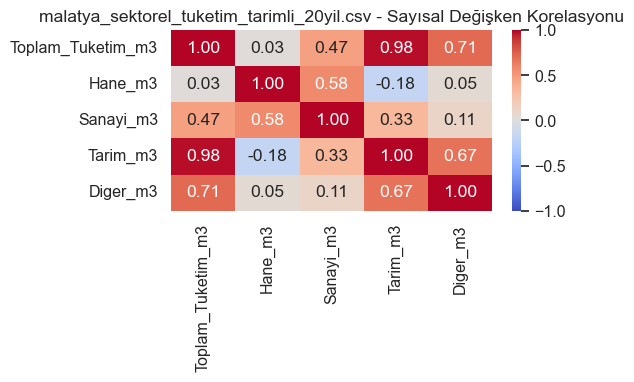

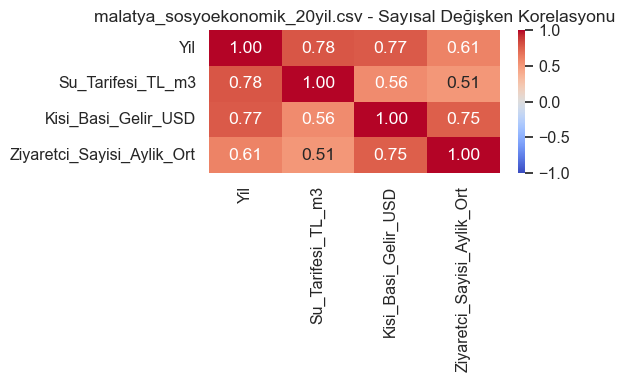

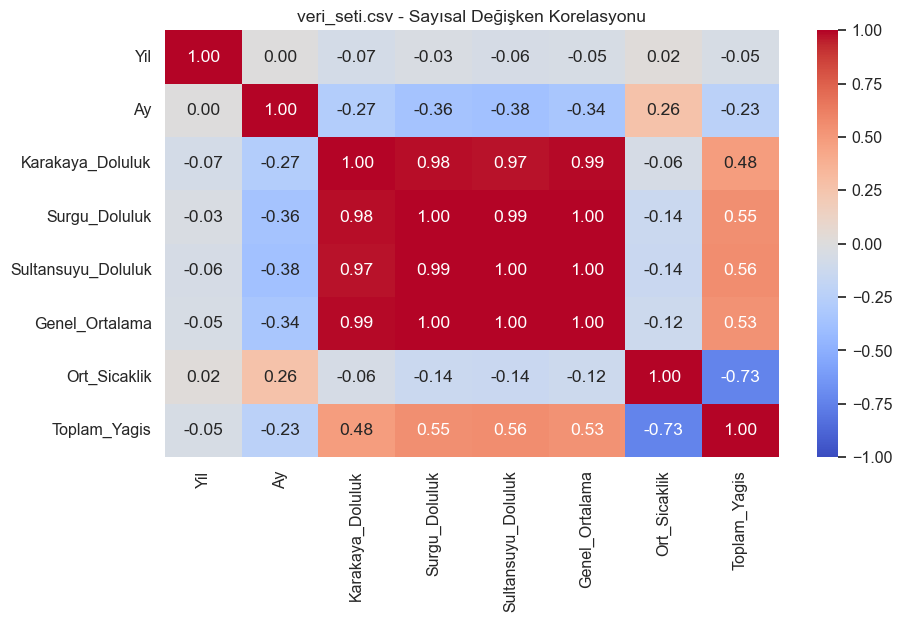

In [13]:
for name, df in typed_data.items():
    numeric = df.select_dtypes(include=['number'])
    if numeric.shape[1] < 2:
        print(f"\n{name}: Korelasyon analizi için yeterli sayısal sütun yok.")
        continue

    corr = numeric.corr()
    plt.figure(figsize=(max(6, corr.shape[0] * 1.2), max(4, corr.shape[1] * 0.8)))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(name + ' - Sayısal Değişken Korelasyonu')
    plt.tight_layout()
    plt.show()